Epoch 1:   0%|          | 0/427 [00:00<?, ?it/s]

Epoch 1 | T-Loss: 0.509 | V-Loss: 1.036 | V-AUC: 0.9043


Epoch 2:   0%|          | 0/427 [00:00<?, ?it/s]

Epoch 2 | T-Loss: 0.422 | V-Loss: 0.418 | V-AUC: 0.9331


Epoch 3:   0%|          | 0/427 [00:00<?, ?it/s]

...

Epoch 8 | T-Loss: 0.294 | V-Loss: 0.453 | V-AUC: 0.9351


Epoch 9:   0%|          | 0/427 [00:00<?, ?it/s]

Epoch 9 | T-Loss: 0.279 | V-Loss: 0.422 | V-AUC: 0.9399


Epoch 10:   0%|          | 0/427 [00:00<?, ?it/s]

Epoch 10 | T-Loss: 0.264 | V-Loss: 0.818 | V-AUC: 0.9177


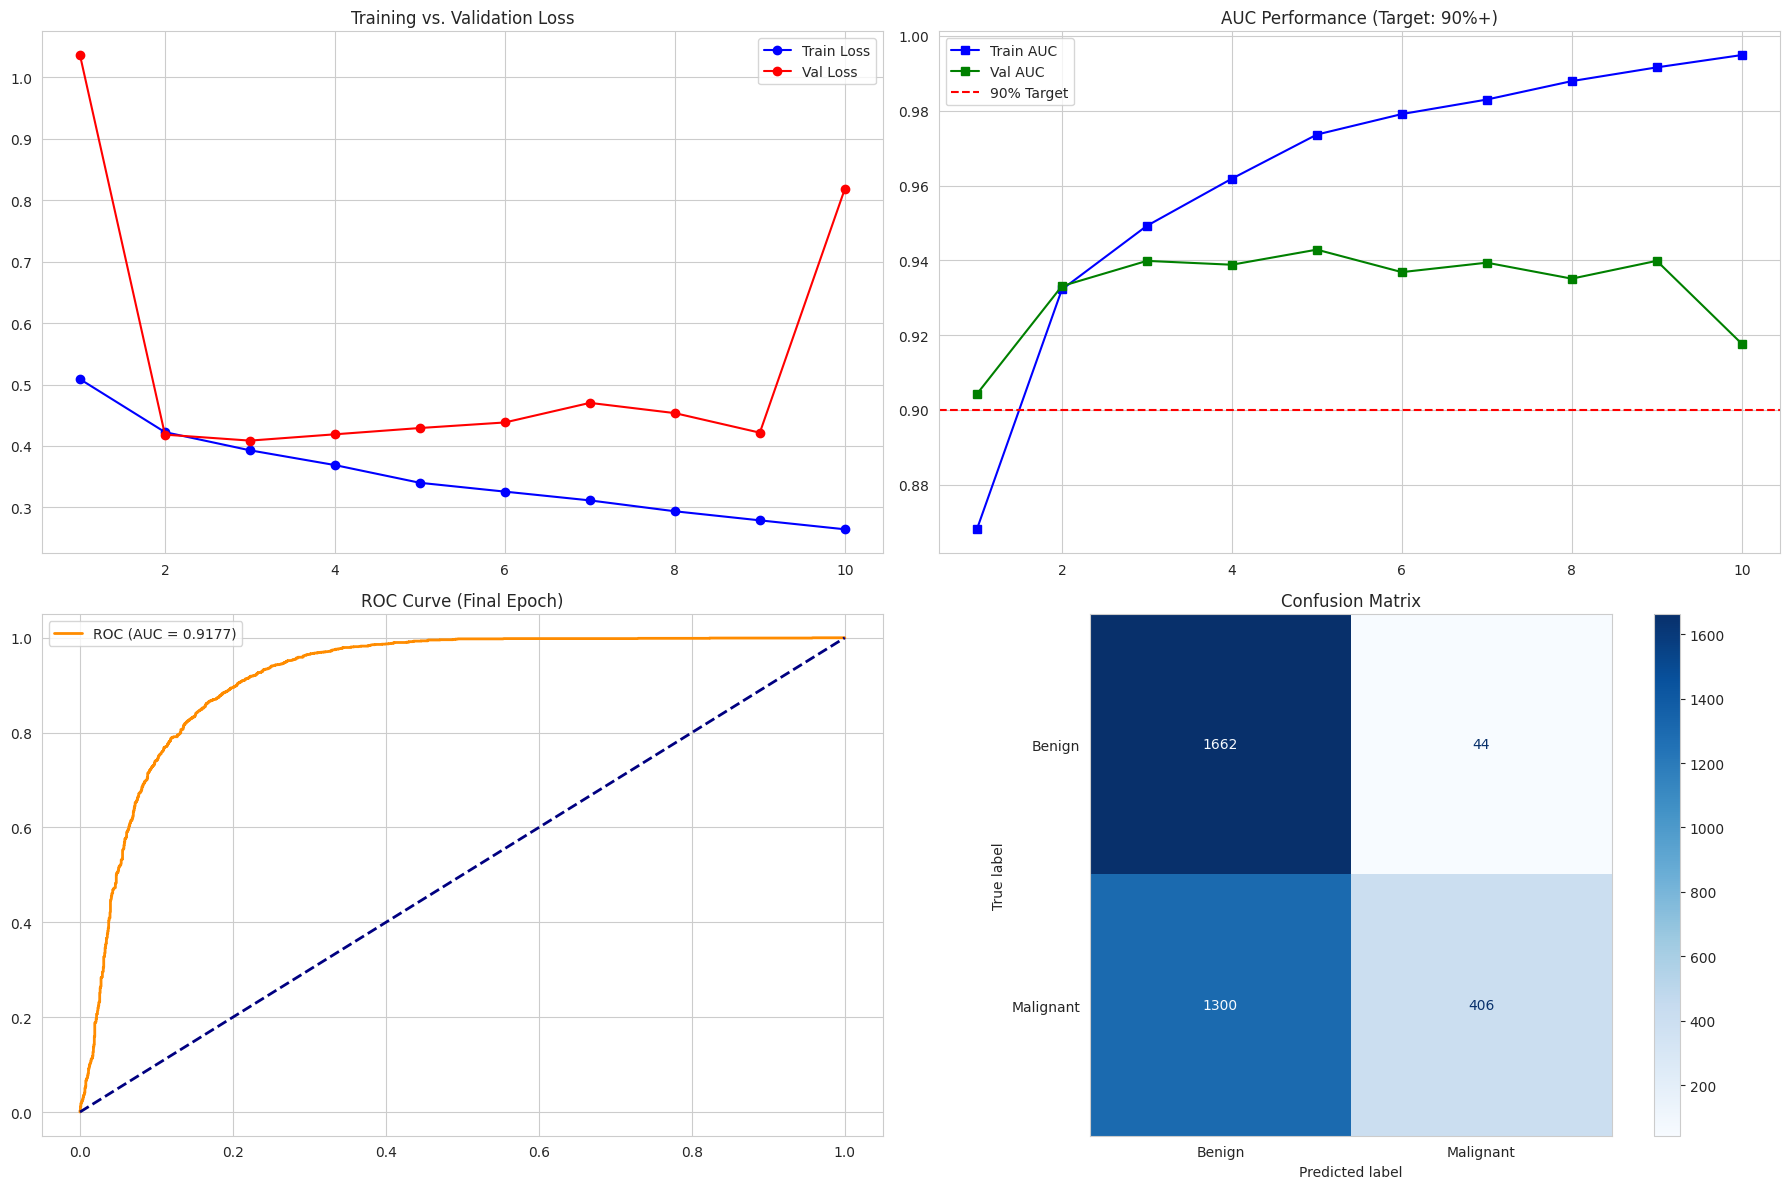

In [16]:
import os, glob, torch, gc, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

class CFG:
    CSV_PATH = "/kaggle/input/datasets/ahmedmohsen202301138/final-processed-metadata/final_preprocessed_data.csv"
    IMG_ROOT = "/kaggle/input/"
    IMG_SIZE = 224
    BATCH = 32
    EPOCHS = 10    
    LR = 4e-5             
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    SEED = 42

class ISIC_MaxViT_SOTA(nn.Module):
    def __init__(self, meta_dim):
        super().__init__()
        try:
            full_model = models.maxvit_t(weights="IMAGENET1K_V1")
        except:
            full_model = models.maxvit_t(pretrained=True)
            
        self.backbone = nn.Sequential(
            full_model.stem,
            *full_model.blocks
        )
        
        self.gradients = None
        self.img_proj = nn.Linear(512, 512)
        self.meta_enc = nn.Sequential(
            nn.Linear(meta_dim, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Linear(256, 512)
        )
        
        self.gate = nn.Sequential(nn.Linear(1024, 512), nn.Sigmoid())
        self.classifier = nn.Sequential(
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.4), nn.Linear(128, 2)
        )

    def activations_hook(self, grad): self.gradients = grad

    def forward(self, img, meta):
        x = self.backbone(img) 
        if x.requires_grad: x.register_hook(self.activations_hook)
        self.last_layer = x
        img_f = self.img_proj(torch.mean(x, dim=(2, 3)))
        meta_f = self.meta_enc(meta)
        combined = torch.cat([img_f, meta_f], dim=1)
        g = self.gate(combined)
        fused = g * img_f + (1 - g) * meta_f
        return self.classifier(fused)

class ISICDataset(Dataset):
    def __init__(self, df, file_map, tfm=None):
        self.df, self.file_map, self.tfm = df.reset_index(drop=True), file_map, tfm
        self.meta_cols = [c for c in df.columns if c not in ["image","isic_id","patient_id","class"]]
        self.meta = torch.tensor(df[self.meta_cols].values.astype(np.float32))
        self.labels = torch.tensor(df["class"].values, dtype=torch.long)

    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        isic_id = str(self.df.iloc[i]["isic_id"])
        path = self.file_map.get(isic_id)
        img = Image.open(path).convert("RGB") if path and os.path.exists(path) else Image.new("RGB", (224,224))
        if self.tfm: img = self.tfm(img)
        return img, self.meta[i], self.labels[i]

def plot_training_results(t_aucs, v_aucs, t_losses, v_losses, labels, probs):
    epochs = range(1, len(t_aucs) + 1)
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(2, 2, figsize=(18, 12))
    
    ax[0, 0].plot(epochs, t_losses, 'b-o', label='Train Loss')
    ax[0, 0].plot(epochs, v_losses, 'r-o', label='Val Loss')
    ax[0, 0].set_title('Training vs. Validation Loss'); ax[0, 0].legend()

    ax[0, 1].plot(epochs, t_aucs, 'b-s', label='Train AUC')
    ax[0, 1].plot(epochs, v_aucs, 'g-s', label='Val AUC')
    ax[0, 1].axhline(y=0.90, color='r', linestyle='--', label='90% Target')
    ax[0, 1].set_title('AUC Performance (Target: 90%+)'); ax[0, 1].legend()

    fpr, tpr, _ = roc_curve(labels, probs)
    ax[1, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {v_aucs[-1]:.4f})')
    ax[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[1, 0].set_title('ROC Curve (Final Epoch)'); ax[1, 0].legend()

    preds = [1 if p > 0.5 else 0 for p in probs]
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
    disp.plot(cmap='Blues', ax=ax[1, 1]); ax[1, 1].set_title('Confusion Matrix'); ax[1, 1].grid(False)

    plt.tight_layout(); plt.show()

def train():
    gc.collect(); torch.cuda.empty_cache()
    
    all_images = glob.glob(os.path.join(CFG.IMG_ROOT, "**/*.jpg"), recursive=True)
    file_map = {os.path.splitext(os.path.basename(f))[0]: f for f in all_images}
    df = pd.read_csv(CFG.CSV_PATH)
    meta_cols = [c for c in df.columns if c not in ["image","isic_id","patient_id","class"]]
    tr_df, vl_df = train_test_split(df, test_size=0.2, stratify=df["class"], random_state=CFG.SEED)
    
    counts = tr_df['class'].value_counts().to_dict()
    weights = [1.0/counts[l] for l in tr_df['class']]
    sampler = WeightedRandomSampler(weights, len(weights))

    tfm = transforms.Compose([
        transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

    tr_dl = DataLoader(ISICDataset(tr_df, file_map, tfm), batch_size=CFG.BATCH, sampler=sampler, num_workers=2)
    vl_dl = DataLoader(ISICDataset(vl_df, file_map, tfm), batch_size=CFG.BATCH, num_workers=0)

    model = ISIC_MaxViT_SOTA(len(meta_cols)).to(CFG.DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=0.05)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler = torch.amp.GradScaler('cuda')

    h_t_auc, h_v_auc, h_t_loss, h_v_loss = [], [], [], []

    for epoch in range(CFG.EPOCHS):
        model.train(); total_t_loss = 0; t_probs, t_labels = [], []
        for img, meta, y in tqdm(tr_dl, desc=f"Epoch {epoch+1}"):
            img, meta, y = img.to(CFG.DEVICE), meta.to(CFG.DEVICE), y.to(CFG.DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda'):
                out = model(img, meta); loss = criterion(out, y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            total_t_loss += loss.item()
            t_probs.extend(F.softmax(out, 1)[:, 1].detach().cpu().numpy())
            t_labels.extend(y.cpu().numpy())
        
        model.eval(); v_probs, v_labels, total_v_loss = [], [], 0
        with torch.no_grad():
            for img, meta, y in vl_dl:
                img, meta, y = img.to(CFG.DEVICE), meta.to(CFG.DEVICE), y.to(CFG.DEVICE)
                with torch.amp.autocast('cuda'):
                    out = model(img, meta); v_loss = criterion(out, y)
                total_v_loss += v_loss.item()
                v_probs.extend(F.softmax(out, 1)[:, 1].cpu().numpy())
                v_labels.extend(y.cpu().numpy())
        
        h_t_loss.append(total_t_loss/len(tr_dl))
        h_v_loss.append(total_v_loss/len(vl_dl))
        h_t_auc.append(roc_auc_score(t_labels, t_probs))
        h_v_auc.append(roc_auc_score(v_labels, v_probs))
        
        print(f"Epoch {epoch+1} | T-Loss: {h_t_loss[-1]:.3f} | V-Loss: {h_v_loss[-1]:.3f} | V-AUC: {h_v_auc[-1]:.4f}")

    plot_training_results(h_t_auc, h_v_auc, h_t_loss, h_v_loss, np.array(v_labels), np.array(v_probs))
    
    return model, vl_df, file_map, meta_cols

if __name__ == "__main__":
    model, vl_df, file_map, meta_cols = train()

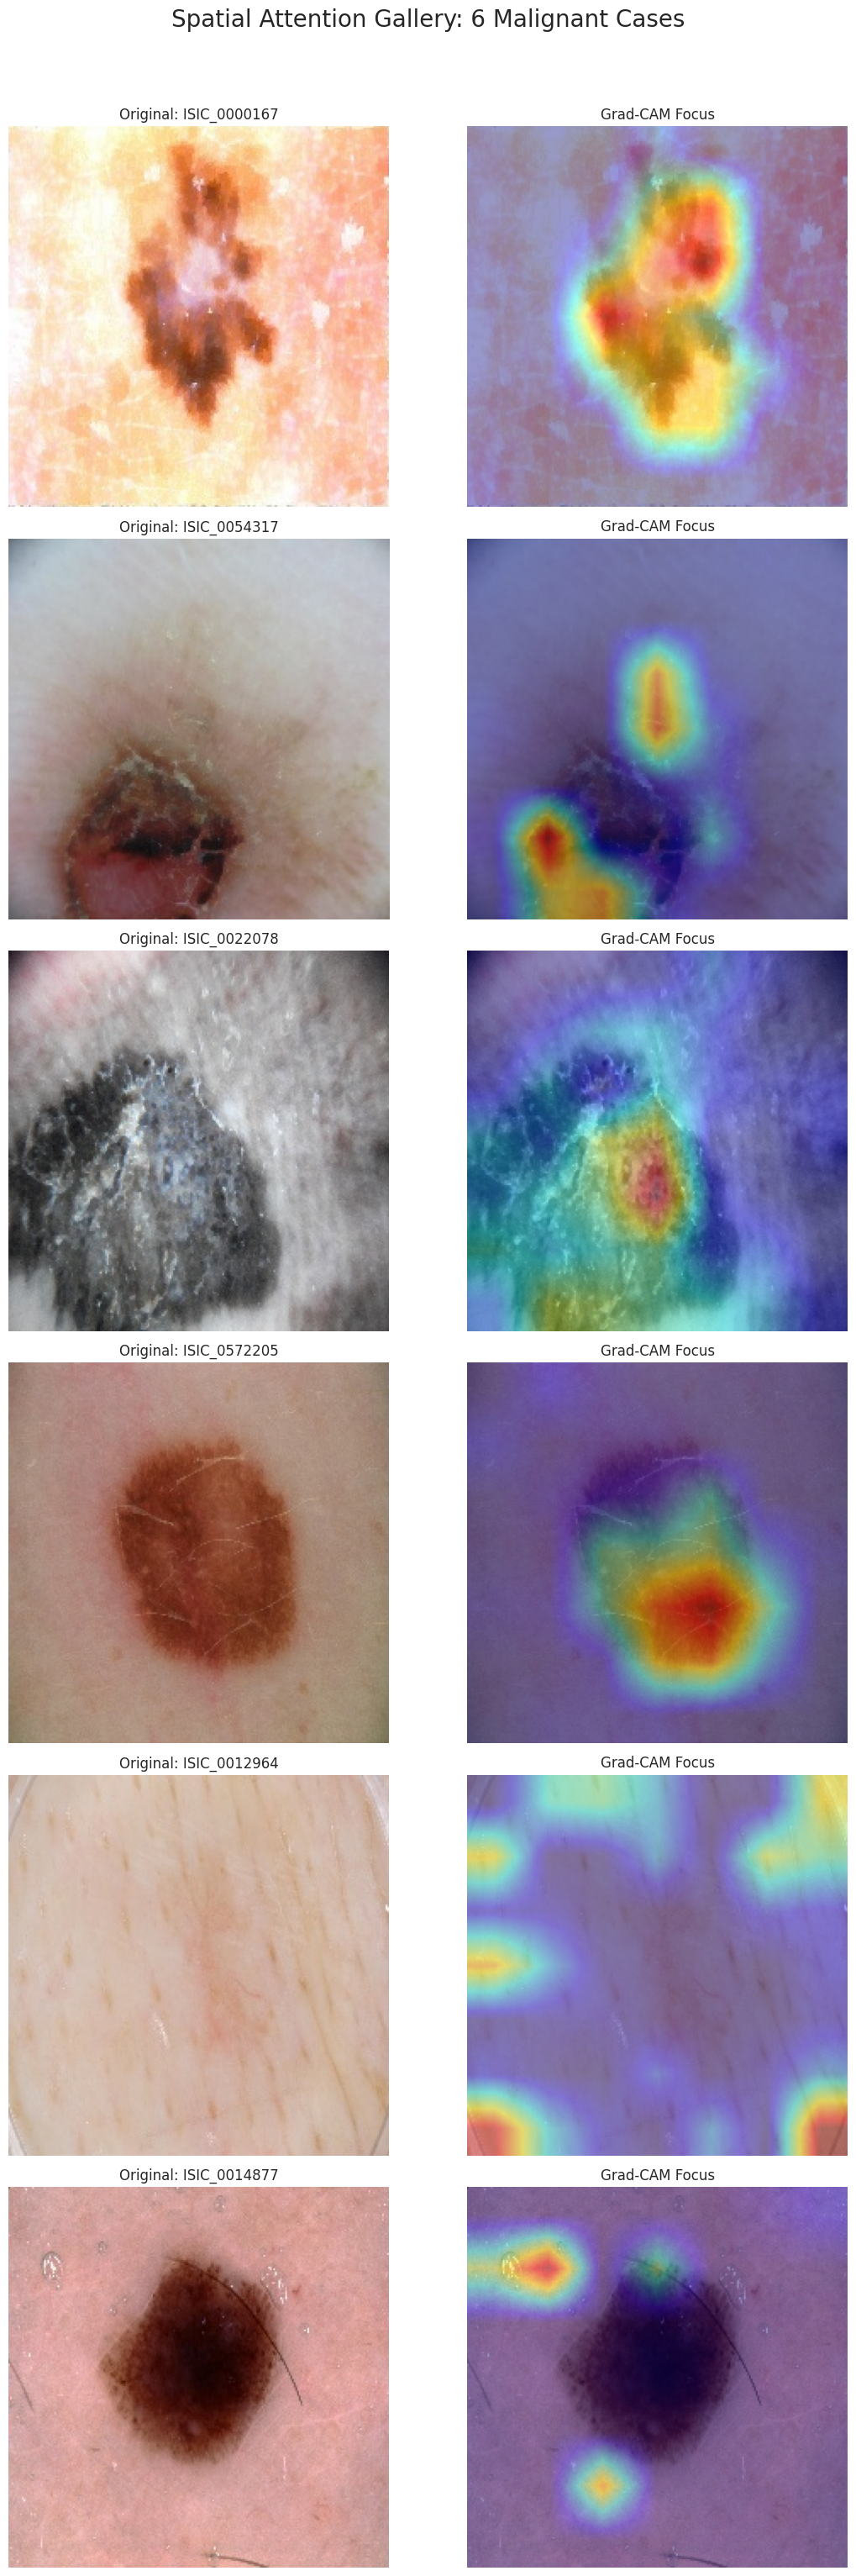


Calculating Global SHAP impact for 6 samples...


  0%|          | 0/6 [00:00<?, ?it/s]


--- Global Metadata Impact (Beeswarm View) ---


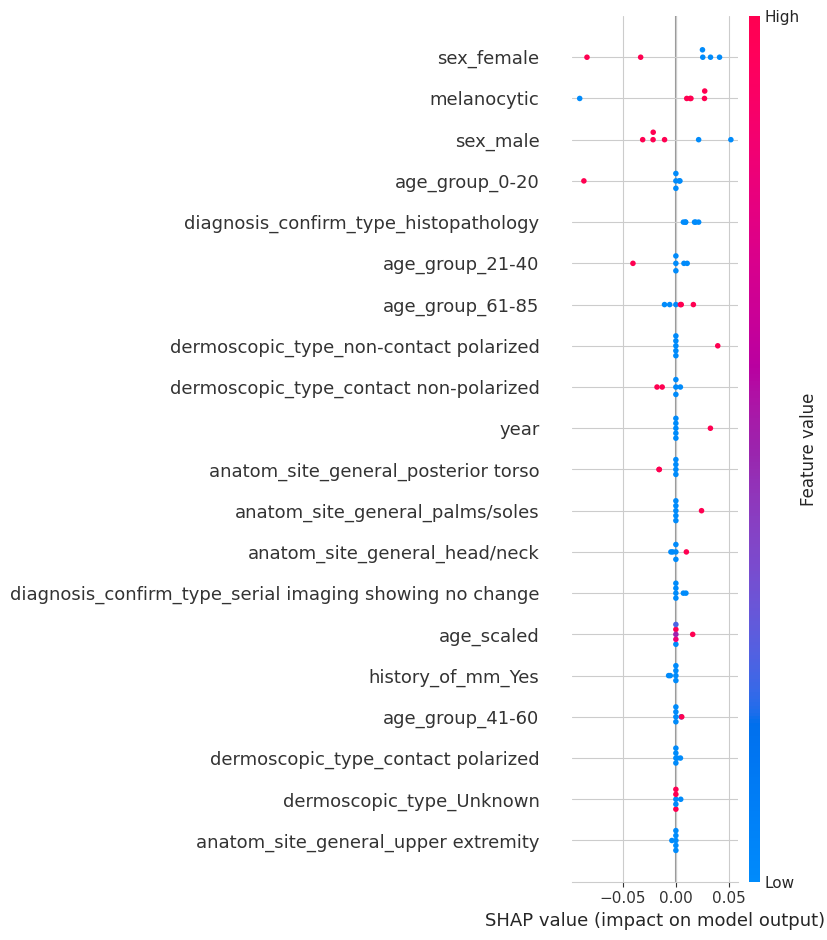

In [18]:
import shap
import cv2
import numpy as np
import matplotlib.pyplot as plt
import gc
import torch
from torchvision import transforms
from PIL import Image

def run_comprehensive_xai_gallery(model, df, file_map, meta_cols, num_samples=5):
    model.eval()
    device = next(model.parameters()).device
    malignant_df = df[df['class'] == 1].sample(min(num_samples, len(df[df['class']==1])))
    
    fig, axes = plt.subplots(len(malignant_df), 2, figsize=(12, 5 * len(malignant_df)))
    plt.suptitle(f"Spatial Attention Gallery: {len(malignant_df)} Malignant Cases", fontsize=20, y=1.02)

    tfm = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    for i, (idx, row) in enumerate(malignant_df.iterrows()):
        isic_id = str(row['isic_id'])
        img_path = file_map.get(isic_id)
        
        orig_img = Image.open(img_path).convert("RGB").resize((224, 224))
        input_tensor = tfm(orig_img).unsqueeze(0).to(device)
        meta_tensor = torch.tensor(row[meta_cols].values.astype(np.float32)).unsqueeze(0).to(device)

        model.zero_grad()
        output = model(input_tensor, meta_tensor)
        output[:, 1].backward() 
        
        grads = model.gradients.detach()
        acts = model.last_layer.detach()
        weights = torch.mean(grads, dim=[0, 2, 3])
        
        for chan in range(acts.size(1)):
            acts[:, chan, :, :] *= weights[chan]
            
        heatmap = torch.mean(acts, dim=1).squeeze().cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap /= (np.max(heatmap) + 1e-8)

        heatmap_cv = cv2.applyColorMap(np.uint8(255 * cv2.resize(heatmap, (224, 224))), cv2.COLORMAP_JET)
        heatmap_cv = cv2.cvtColor(heatmap_cv, cv2.COLOR_BGR2RGB)
        grad_cam_blend = cv2.addWeighted(np.uint8(255 * (np.float32(orig_img)/255)), 0.6, heatmap_cv, 0.4, 0)

        axes[i, 0].imshow(orig_img)
        axes[i, 0].set_title(f"Original: {isic_id}")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(grad_cam_blend)
        axes[i, 1].set_title(f"Grad-CAM Focus")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"\nCalculating Global SHAP impact for {len(malignant_df)} samples...")
    
    def shap_predict_batched(meta_np):
        batch_size = 8
        all_probs = []
        for j in range(0, len(meta_np), batch_size):
            chunk = meta_np[j : j + batch_size]
            m_t = torch.tensor(chunk).float().to(device)
            d_img = torch.zeros((len(chunk), 3, 224, 224)).to(device)
            with torch.no_grad():
                out = model(d_img, m_t)
                all_probs.append(torch.softmax(out, dim=1)[:, 1].cpu().numpy())
            del m_t, d_img, out
            torch.cuda.empty_cache()
        return np.concatenate(all_probs)

    background = shap.sample(df[meta_cols].values, 50)
    explainer = shap.KernelExplainer(shap_predict_batched, background)
    
    shap_values = explainer.shap_values(malignant_df[meta_cols].values, nsamples=200)

    print("\n--- Global Metadata Impact (Beeswarm View) ---")
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, malignant_df[meta_cols], feature_names=meta_cols, plot_type="dot")
    
    gc.collect(); torch.cuda.empty_cache()

run_comprehensive_xai_gallery(model, vl_df, file_map, meta_cols, num_samples=6)